In [1]:
import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

C:\Users\uttar\AppData\Local\Temp\ipykernel_1524\993799905.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# builtarea = ['surface', 'volume']
def read_Data(path, merged_column_names, builtarea):
    df_merged = pd.DataFrame(columns = ['GEOID'])
    if builtarea == 'surface':
        divideby = 1000000
    elif builtarea == 'volume':
        divideby = 1000000 # volume in m-Km^2
    else:
        print('Check input format')
        
    merged_column_names.append(builtarea)
    # print(merged_column_names)
    os.chdir(path)
    for file in glob.glob("*.csv"):
        df = pd.read_csv(file, dtype={'GEOID':str})
        df['TOTALAREA_SQKM'] = df[['ALAND', 'AWATER']].sum(axis=1)/1000000
        df[builtarea] = df['sum']/divideby
        df = df.sort_values(by='GEOID').reset_index(drop=True)
        # print(df.columns)
        print('Shape of the dataframe:', df.shape, 'and Total built area in square kilometers: ', df[builtarea].sum())
        df_merged = df_merged.merge(df, on='GEOID', suffixes = ('', file[16:-4]), how = 'outer')

    return df_merged

In [3]:
surface_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Surface\\'
volume_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Volume\\'

column_names = ['GEOID', 'NAMELSAD', 'sum']

df_surface = read_Data(surface_path, column_names, 'surface')
df_volume = read_Data(volume_path, column_names, 'volume')

Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  21644.92394082745
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  24308.169725549018
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  27090.809701211765
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  30132.93283033333
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  34211.55894956471
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  36204.79538878432
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  37375.57910632157
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  157313.24840056078
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  173143.43487209803
Shape of the dataframe: (32188, 8) and Total built area in square kilometers:  191191.21421247453
Shape of the dataframe: (

In [4]:
# df_volume.filter(regex=("volume*")).columns # '1714000'
# 168.465656 - 121.339918
# df_volume[['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020']]

In [5]:
df_surface['change_80_90'] = (df_surface['surface_1990'] - df_surface['surface'])
df_surface['change_90_00'] = (df_surface['surface_2000'] - df_surface['surface_1990'])
df_surface['change_00_10'] = (df_surface['surface_2010'] - df_surface['surface_2000'])
df_surface['change_10_20'] = (df_surface['surface_2020'] - df_surface['surface_2010'])

In [6]:
df_surface.columns

Index(['GEOID', 'STATEFP', 'NAMELSAD', 'ALAND', 'AWATER', 'sum',
       'TOTALAREA_SQKM', 'surface', 'STATEFP_1990', 'NAMELSAD_1990',
       'ALAND_1990', 'AWATER_1990', 'sum_1990', 'TOTALAREA_SQKM_1990',
       'surface_1990', 'STATEFP_1995', 'NAMELSAD_1995', 'ALAND_1995',
       'AWATER_1995', 'sum_1995', 'TOTALAREA_SQKM_1995', 'surface_1995',
       'STATEFP_2000', 'NAMELSAD_2000', 'ALAND_2000', 'AWATER_2000',
       'sum_2000', 'TOTALAREA_SQKM_2000', 'surface_2000', 'STATEFP_2010',
       'NAMELSAD_2010', 'ALAND_2010', 'AWATER_2010', 'sum_2010',
       'TOTALAREA_SQKM_2010', 'surface_2010', 'STATEFP_2015', 'NAMELSAD_2015',
       'ALAND_2015', 'AWATER_2015', 'sum_2015', 'TOTALAREA_SQKM_2015',
       'surface_2015', 'STATEFP_2020', 'NAMELSAD_2020', 'ALAND_2020',
       'AWATER_2020', 'sum_2020', 'TOTALAREA_SQKM_2020', 'surface_2020',
       'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20'],
      dtype='object')

In [7]:
210-173, 233-210, 251-233

(37, 23, 18)

In [8]:
# df_volume.filter(regex=("volume*")).columns

In [9]:
df_volume['Vchange_80_90'] = (df_volume['volume_1990'] - df_volume['volume'])
df_volume['Vchange_90_00'] = (df_volume['volume_2000'] - df_volume['volume_1990'])
df_volume['Vchange_00_10'] = (df_volume['volume_2010'] - df_volume['volume_2000'])
df_volume['Vchange_10_20'] = (df_volume['volume_2020'] - df_volume['volume_2010'])

In [10]:
df_volume[df_volume['NAMELSAD'] == 'Chicago city'][['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010',
       'volume_2015', 'volume_2020', 'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20']]

,GEOID,NAMELSAD,volume,volume_1990,volume_1995,volume_2000,volume_2010,volume_2015,volume_2020,Vchange_80_90,Vchange_90_00,Vchange_00_10,Vchange_10_20
6708,1714000,Chicago city,1591.656218,1719.146309,1737.019687,1755.12382,1764.979699,1770.182872,1776.373263,127.490091,35.977511,9.855879,11.393564


In [11]:
# df_volume[['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010',
#        'volume_2015', 'volume_2020', 'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20']].sort_values('volume_2020', ascending = False).head(20)

In [12]:
df_surface.filter(regex = 'surface*').columns

Index(['surface', 'surface_1990', 'surface_1995', 'surface_2000',
       'surface_2010', 'surface_2015', 'surface_2020'],
      dtype='object')

In [13]:
df = df_volume.merge(df_surface[['GEOID','surface', 'surface_1990', 'surface_1995', 
            'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
            'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']], on = 'GEOID')

In [14]:
df['H_2020'] = df['volume_2020'] / df['surface_2020']
df['H_2010'] = df['volume_2010'] / df['surface_2010']
df['H_2000'] = df['volume_2000'] / df['surface_2000']
df['H_1990'] = df['volume_1990'] / df['surface_1990']
df['H_1980'] = df['volume'] / df['surface']

In [15]:
# df[df['GEOID'].str.startswith('06')][['GEOID', 'NAMELSAD', 'surface_2000', 'surface_2020', 'change_80_90', 'change_90_00','change_00_10', 'change_10_20', 
#                                       'volume_2000', 'volume_2020', 'Vchange_10_20', 'H_1980', 'H_1990', 
#                                       'H_2020']].sort_values(by = 'change_10_20', ascending = False).head(50)

In [16]:
import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
places_US.shape

(32188, 17)

In [17]:
df.filter(regex=("H_*")).columns

Index(['H_2020', 'H_2010', 'H_2000', 'H_1990', 'H_1980'], dtype='object')

In [18]:
df_selected = df[['GEOID', 'TOTALAREA_SQKM_2020', 'surface', 'surface_1990', 'surface_1995', 'surface_2000',
       'surface_2010', 'surface_2015', 'surface_2020', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010',
       'volume_2015', 'volume_2020', 'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20',
       'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20', 'H_2020', 'H_2010', 'H_2000', 'H_1990', 'H_1980']]

In [19]:
df_selected.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\GHSL_AREA_VOL_cleaned.csv')

In [20]:
df_with_geom = places_US.merge(df_selected, on = 'GEOID')

In [21]:
df_with_geom.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'TOTALAREA_SQKM_2020',
       'surface', 'surface_1990', 'surface_1995', 'surface_2000',
       'surface_2010', 'surface_2015', 'surface_2020', 'volume', 'volume_1990',
       'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015',
       'volume_2020', 'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10',
       'Vchange_10_20', 'change_80_90', 'change_90_00', 'change_00_10',
       'change_10_20', 'H_2020', 'H_2010', 'H_2000', 'H_1990', 'H_1980'],
      dtype='object')

In [22]:
df_with_geom = df_with_geom.to_crs('EPSG:9311')

In [23]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.27,5.27))
# for ax in axes.flatten():
#     continental_ax = ax          
#     # Set bounds to fit desired areas in each plot
#     continental_ax.set_xlim(-2257388.37, 2695859.75)
#     continental_ax.set_ylim(-2546944.04, 808080.9)
#     df_with_geom.plot(column = 'change_10_20', 
#              ax=continental_ax,
#              legend = True)

In [24]:
df_with_geom['landAreaSqkm'] = df_with_geom['ALAND']/1000000
df_with_geom['%built'] = df_with_geom['surface_2020']/df_with_geom['landAreaSqkm']
df_with_geom[['STATEFP', 'GEOID', 'NAME', 'landAreaSqkm',
       'surface_2020',  '%built', 'volume_2020']].sort_values(by= '%built').tail(15)

,STATEFP,GEOID,NAME,landAreaSqkm,surface_2020,%built,volume_2020
3609,06,0684774,West Puente Valley,4.842002,1.988661,0.410711,15.320071
5110,12,1243475,Matlacha,0.514115,0.211634,0.411647,0.967764
2200,06,0614974,Commerce,16.921570,6.975278,0.412212,79.528724
2810,06,0621034,East Rancho Dominguez,2.127127,0.876944,0.412267,6.371021
16942,34,3428650,Guttenberg,0.499906,0.206341,0.412760,3.149987
3161,06,0646436,Mayflower Village,1.777078,0.735651,0.413966,5.776102
2812,06,0621096,East San Gabriel,5.641695,2.336664,0.414178,19.130860
3385,06,0663050,Rossmoor,4.038884,1.683789,0.416895,12.291985
3560,06,0681638,Valinda,5.213065,2.183775,0.418904,16.367501
3470,06,0673167,South Monrovia Island,1.419511,0.596333,0.420097,4.542190


In [25]:
# df_with_geom[df_with_geom['STATEFP'] == '48'][['surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015','surface_2020']].T.plot()

In [26]:
df_with_geom.shape

(32188, 47)

In [27]:
df_YearBuilt = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\Housing Data ACS\HousingDataCleaned.csv', index_col = 0)
df_YearBuilt['GEOID'] = df_YearBuilt['GEOID'].str[9:]

In [28]:
df_combined = df_with_geom.merge(df_YearBuilt, on = 'GEOID')
df_combined.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME_x', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'TOTALAREA_SQKM_2020',
       'surface', 'surface_1990', 'surface_1995', 'surface_2000',
       'surface_2010', 'surface_2015', 'surface_2020', 'volume', 'volume_1990',
       'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015',
       'volume_2020', 'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10',
       'Vchange_10_20', 'change_80_90', 'change_90_00', 'change_00_10',
       'change_10_20', 'H_2020', 'H_2010', 'H_2000', 'H_1990', 'H_1980',
       'landAreaSqkm', '%built', 'NAME_y', 'HUs_Total', 'YB_2020_or_later',
       'YB_2010_2019', 'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979',
       'YB_1940_1959', 'YB_1939_or_earlier', 'STRUC_detached_1',
       'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4', 'STRUC_apt_5_9',
       'STRUC_apt_10_more', 'STRUC_mobile_or_other', 'H

In [29]:
df_combined['weighted_avg_age'] = ((2024-1939)*df_combined['YB_1939_or_earlier'] + (2024-1950)*df_combined['YB_1940_1959'] + (2024-1970)*df_combined['YB_1960_1979'] +
                                  (2024-1990)*df_combined['YB_1980_1999'] + (2024-2004)*df_combined['YB_2000_2009'] + (2024-2014)*df_combined['YB_2010_2019'] + 
                                  (2024-2022)*df_combined['YB_2020_or_later'])/100

In [30]:
df_combined[['STATEFP', 'NAMELSAD','YB_2020_or_later','YB_2010_2019', 'YB_2000_2009', 'Year_Built', 'Percent_Built', 'weighted_avg_age']]

,STATEFP,NAMELSAD,YB_2020_or_later,YB_2010_2019,YB_2000_2009,Year_Built,Percent_Built,weighted_avg_age
0,01,Ardmore town,0.0,12.0,11.8,YB_1980_1999,31.8,42.987
1,01,Mooresville town,0.0,3.1,9.4,YB_1939_or_earlier,71.9,69.229
2,01,Somerville town,0.0,5.4,8.9,YB_1980_1999,46.7,40.694
3,01,Trinity town,0.0,9.8,12.0,YB_1980_1999,39.8,38.508
4,01,Goshen town,0.0,6.1,2.6,YB_1980_1999,32.5,51.828
...,...,...,...,...,...,...,...,...
31900,72,Voladoras comunidad,0.0,15.0,12.2,YB_1960_1979,39.0,44.566
31901,72,Yabucoa zona urbana,0.0,2.6,7.6,YB_1960_1979,54.2,47.254
31902,72,Yauco zona urbana,0.0,0.6,5.1,YB_1960_1979,44.8,45.245
31903,72,Yaurel comunidad,0.0,0.0,4.0,YB_1980_1999,52.3,43.134


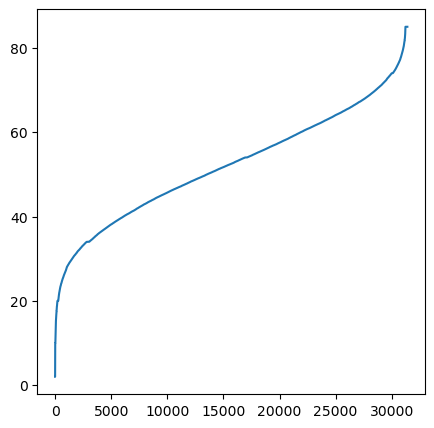

In [31]:
from pylab import *
fig = figure( figsize=(5,5) )
ax  = fig.add_subplot(111)
ax.plot( np.arange(df_combined.shape[0]), df_combined['weighted_avg_age'].sort_values())

### Fit linear reg

In [109]:
def find_scale_parameters(df, infra_col, pop_col):
    df['log_pop_col'] = np.log(df[pop_col])
    df['log_infra_col'] = np.log(df[infra_col])
    
    # Check plot how the log-log plot looks?
    # ADD A QUESTION ASKING WHETHER A PLOT OR NOT???
    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    # print(model.summary())
    print(model.params)
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params

In [110]:
df_combined.columns
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', 
                            index_col  = 0, dtype = {'GEOID': str})

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', 
                            index_col  = 0, dtype = {'GEOID': str})

df_population = df_population.merge(df_attributes[['GEOID', 'city type']], on = 'GEOID')

building_with_pop = df_combined.merge(df_population[['GEOID', 'CensusPop_20', 'city type','ALAND',
                                       'State', 'ssp22020', 'ssp22030', 
                                       'ssp22040', 'ssp22050','ssp22060']])

In [115]:
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
stocks_with_pop.shape

(6037, 82)

In [116]:
# find_scale_parameters(stocks_with_pop, infra_col='surface_2020', pop_col = 'CensusPop_20')

Intercept   -7.962858
x            0.921891
dtype: float64

Confidence Intervals: 'log(a)' and 'b' values---
                  0         1
Intercept -8.026351 -7.899365
x          0.914681  0.929102


C:\Users\uttar\AppData\Local\Temp\ipykernel_1524\872894849.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  size = condition.value_counts()[0]


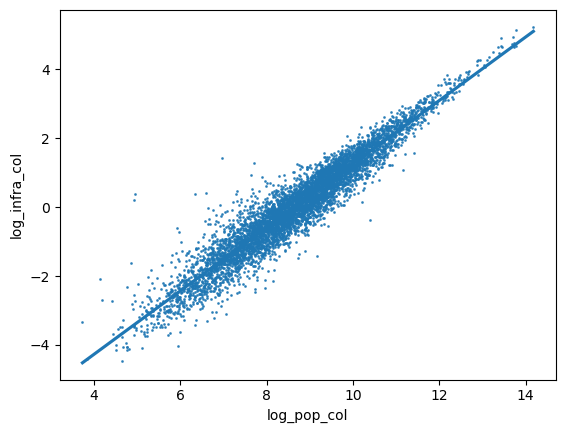

In [117]:
existing_stock_col = 'surface_2020'

x = find_scale_parameters(stocks_with_pop, infra_col= existing_stock_col, pop_col = 'CensusPop_20')
stocks_with_pop['building_mass_reg'] = math.exp(x[2].Intercept)*stocks_with_pop.loc[:, 'CensusPop_20']**x[2].x

# Set the range for the uniform distribution
log_a_lower = x[0][0]
log_a_upper= x[0][1]

beta_lower = x[1][0]
beta_upper= x[1][1]

# Create a uniform distribution
log_a_uniform = np.random.uniform(low=log_a_lower, high=log_a_upper, size=100000)
beta_uniform = np.random.uniform(low=beta_lower, high=beta_upper, size=100000)

# CHECK THE NUMEBR OF TRUE AND FALSE VALUES 
# stocks_with_pop['label'].str.contains('depopulating').value_counts().iloc[0]
stocks_with_pop['added_mass_building'] = np.nan

# Define a condition
condition = stocks_with_pop['ssp22040'] < stocks_with_pop['CensusPop_20'] #stocks_with_pop['label'].str.contains('depopulating')

# Fill the column based on the condition
stocks_with_pop.loc[condition, 'added_mass_building'] = 0
# stocks_with_pop.loc[~condition, 'added_mass_building'] = (np.random.choice(a_uniform, 
#                                                                           size=11776) * stocks_with_pop.loc[~condition, 'CensusPop_20']**(np.random.choice(beta_uniform,
#                                                                           size=11776))) #- stocks_with_pop.loc[~condition, 'building_mass_t']
size = condition.value_counts()[0]
# Define a custom function to generate samples
def sample_function(p):
    return np.exp(np.random.choice(log_a_uniform,  size =1)) * (p ** np.random.choice(beta_uniform, size=1))
# Number of samples to take for each row
num_samples = 100

# Generate samples and calculate the mean for each row
stocks_with_pop.loc[~condition, 'added_mass_building'] = np.mean(np.array([np.random.choice(sample_function(p), size=num_samples) for p in stocks_with_pop.loc[~condition, 'ssp22040']]), axis=1)

stocks_with_pop['additional_mass_building'] = np.where(stocks_with_pop['added_mass_building'] == 0, 0, stocks_with_pop['added_mass_building'] - stocks_with_pop['building_mass_reg'])

stocks_with_pop['per_cap_mass_40'] = (stocks_with_pop[existing_stock_col] + stocks_with_pop['additional_mass_building'])/stocks_with_pop['ssp22040'] 



In [118]:
stocks_with_pop['per_cap_mass'] = stocks_with_pop[existing_stock_col] / stocks_with_pop['CensusPop_20']

stocks_with_pop[['GEOID', 'NAME_y', 'city type', 'surface_2020','additional_mass_building', 'added_mass_building','building_mass_reg', 'per_cap_mass','per_cap_mass_40',
                 'CensusPop_20', 'ssp22020', 'ssp22040']].sort_values(by ='additional_mass_building')

,GEOID,NAME_y,city type,surface_2020,additional_mass_building,added_mass_building,building_mass_reg,per_cap_mass,per_cap_mass_40,CensusPop_20,ssp22020,ssp22040
16490,3901000,"Akron city, Ohio",suburban,25.976339,-0.698996,24.957598,25.656594,0.000136,0.000123,190469,191565.65460,2.056771e+05
12414,3350260,"Nashua city, New Hampshire",suburban,10.853417,-0.636753,12.391501,13.028254,0.000119,0.000110,91322,91813.77292,9.290746e+04
4050,1871000,"South Bend city, Indiana",suburban,17.716579,-0.626921,13.988890,14.615811,0.000171,0.000163,103453,104131.40950,1.051392e+05
3294,1770122,"Skokie village, Illinois",suburban,7.296548,-0.572757,9.330663,9.903420,0.000108,0.000091,67824,68220.86336,7.360545e+04
3875,1822000,"Evansville city, Indiana",suburban,21.777975,-0.537916,15.872131,16.410046,0.000186,0.000161,117298,117971.65550,1.318496e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
21703,4752006,Nashville-Davidson metropolitan government (ba...,suburban,101.507170,22.135467,106.127501,83.992034,0.000147,0.000151,689447,693261.01410,8.190899e+05
290,1235000,"Jacksonville city, Florida",suburban,168.216705,24.460383,137.289799,112.829416,0.000177,0.000173,949611,954611.10030,1.113982e+06
12292,3240000,"Las Vegas city, Nevada",suburban,84.912514,27.907949,106.545584,78.637635,0.000132,0.000133,641903,646158.15200,8.480133e+05
15336,3712000,"Charlotte city, North Carolina",suburban,112.745391,28.231480,132.816088,104.584609,0.000129,0.000131,874579,879683.61630,1.075249e+06


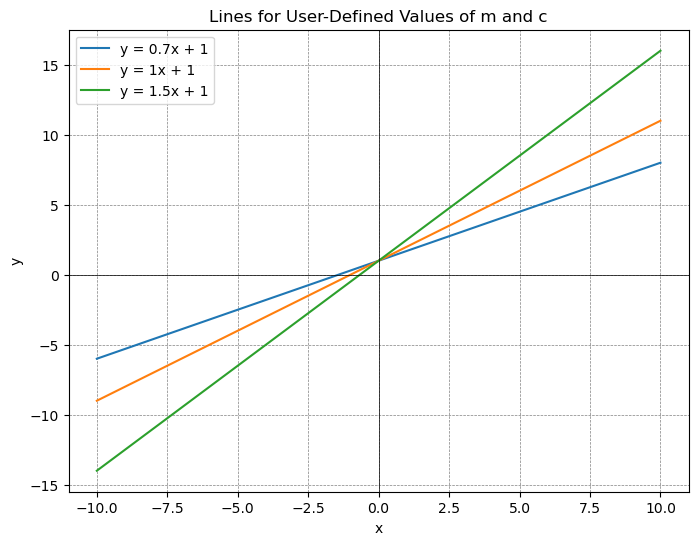

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# User-defined values for m and c
m_values = [0.7, 1, 1.5]
c_values = [1, 1, 1]

# Generate x values
x_values = np.linspace(-10, 10, 100)

# Plot the lines for each combination of m and c
plt.figure(figsize=(8, 6))

for m, c in zip(m_values, c_values):
    y_values = m * x_values + c
    plt.plot(x_values, y_values, label=f'y = {m}x + {c}')

plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title('Lines for User-Defined Values of m and c')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



<Axes: xlabel='weighted_avg_age', ylabel='Density'>

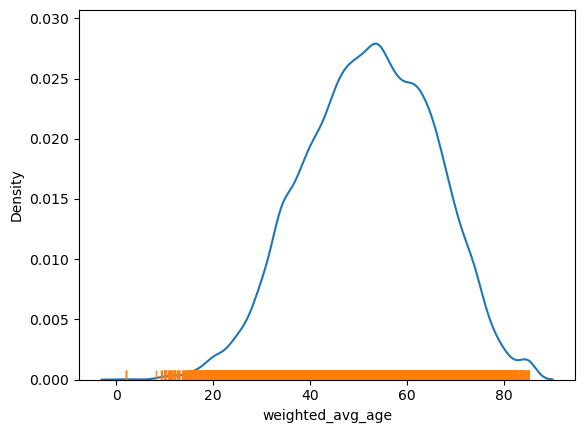

In [37]:
import seaborn as sns
sns.kdeplot(data=df_combined, x = 'weighted_avg_age')
sns.rugplot(data=df_combined, x = 'weighted_avg_age')

In [41]:
df_combined.columns

df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', 
                            index_col  = 0, dtype = {'GEOID': str})
df_combined = df_combined.merge(df_population[['GEOID', 'CensusPop_20', 'label',
                                       'State', 'ssp22020', 'ssp22030', 
                                       'ssp22040', 'ssp22050','ssp22060']])


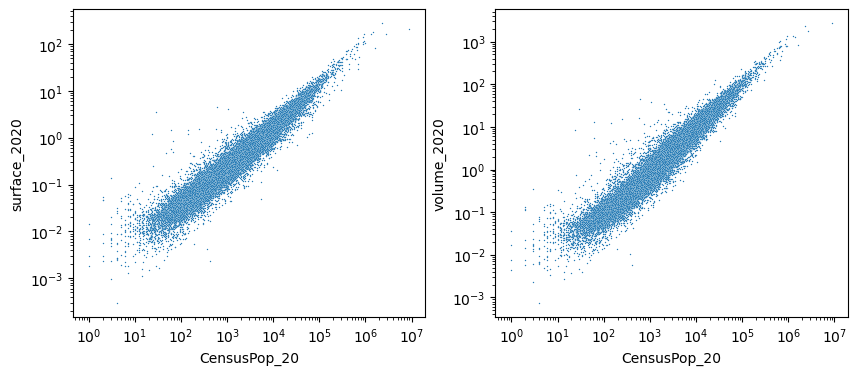

In [101]:
import matplotlib.pyplot as plt
columns = ['surface_2020', 'volume_2020']
f, axes = plt.subplots(ncols = 2, figsize=(10, 4))
for ax, col in zip(axes, columns):
    ax.set(xscale="log", yscale="log")
    sns.scatterplot(ax=ax, data=df_combined, y=col, x ='CensusPop_20', s =1,) #  hue="label",)

In [65]:
df_combined[['surface_2020', 'CensusPop_20', 'log_CensusPop_20', 'log_surface_2020']].isna().sum()

surface_2020        0
CensusPop_20        0
log_CensusPop_20    0
log_surface_2020    0
dtype: int64

In [70]:
df_plot = df_combined[df_combined['CensusPop_20'] !=0]

In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

def find_scale_parameters(df, infra_col, pop_col):
    df['log_pop_col'] = np.log(df[pop_col])
    df['log_infra_col'] = np.log(df[infra_col])
    
    # Check plot how the log-log plot looks?
    # ADD A QUESTION ASKING WHETHER A PLOT OR NOT???
    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
           y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    # print(model.summary())
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    return conf_int



Confidence Intervals: 'log(a)' and 'b' values---
                  0         1
Intercept -7.094393 -7.054476
x          0.817051  0.822601


C:\Users\uttar\miniforge3\envs\pymc_env\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


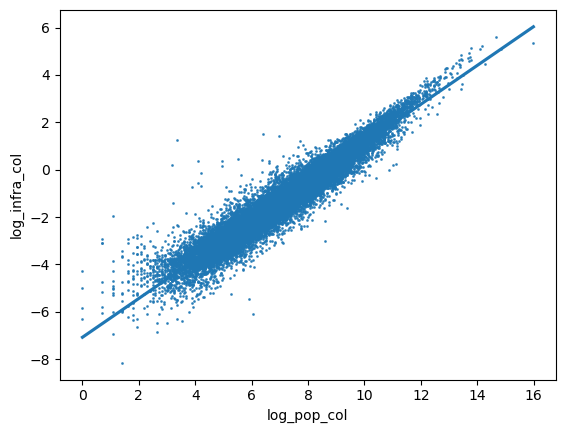

In [131]:
x = find_scale_parameters(df_plot, infra_col = 'surface_2020', pop_col = 'CensusPop_20')

C:\Users\uttar\miniforge3\envs\pymc_env\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)



Confidence Intervals: 'log(a)' and 'b' values---
                  0         1
Intercept -7.002584 -6.954295
x          0.985523  0.992237


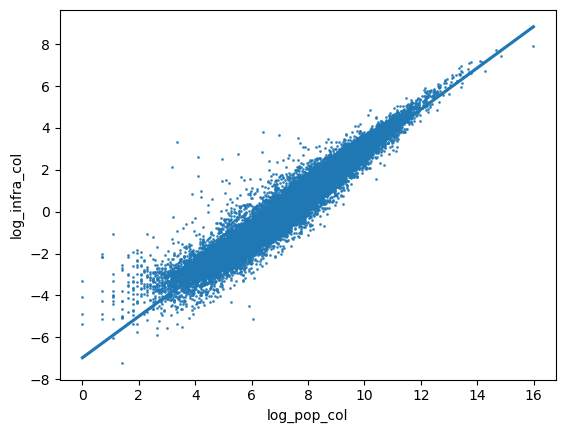

In [132]:
x = find_scale_parameters(df_plot, infra_col = 'volume_2020', pop_col = 'CensusPop_20')

C:\Users\uttar\miniforge3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1323: ImputationWarning: Data in likelihood contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [shape, scale, likelihood_unobserved]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 694 seconds.


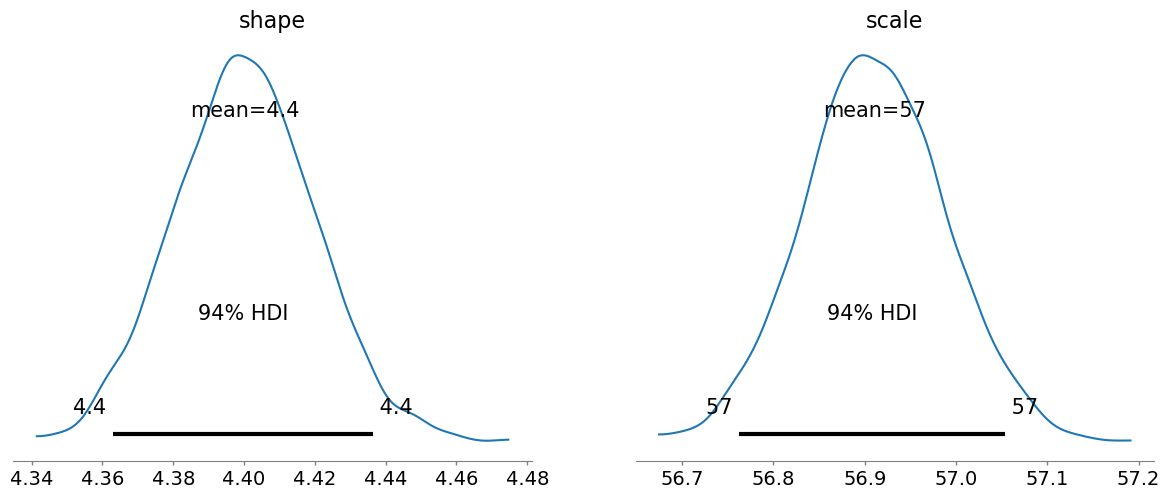

In [33]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# Generate synthetic data from a Weibull distribution
np.random.seed(42)
data = weibull_min.rvs(2, loc=2.8, scale=73.5, size=1000)

# Bayesian model with Weibull prior
with pm.Model() as model:
    # Prior distribution
    shape = pm.HalfNormal('shape', sigma=1)
    scale = pm.HalfNormal('scale', sigma=1)
    
    # Likelihood (observed data)
    likelihood = pm.Weibull('likelihood', alpha=shape, beta=scale, observed=df_combined['weighted_avg_age'])
    
    # Sample from the posterior distribution
    trace = pm.sample(1000, tune=1000)

# Plot the posterior distribution
pm.plot_posterior(trace, var_names=['shape', 'scale'], kind='kde')
plt.show()


In [34]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [35]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# Generate synthetic data from a Weibull distribution
np.random.seed(42)
data = np.random.weibull(2, size=100) * 2

# Bayesian model with Weibull prior
def model(data):
    shape = numpyro.sample('shape', numpyro.distributions.HalfNormal(scale=1))
    scale = numpyro.sample('scale', numpyro.distributions.HalfNormal(scale=1))
    
    likelihood = numpyro.sample('likelihood', numpyro.distributions.Weibull(shape, scale), obs=data)

# Run NUTS (No-U-Turn Sampler) to sample from the posterior distribution
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000, num_chains=1)
mcmc.run(jax.random.PRNGKey(0), data=data)

# Get the posterior samples
samples = mcmc.get_samples()

# Plot the posterior distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(samples['shape'], bins=30, density=True, color='blue', alpha=0.7)
plt.title('Posterior Distribution of Shape')

plt.subplot(1, 2, 2)
plt.hist(samples['scale'], bins=30, density=True, color='red', alpha=0.7)
plt.title('Posterior Distribution of Scale')

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'jax'


DataFrame after assignment:


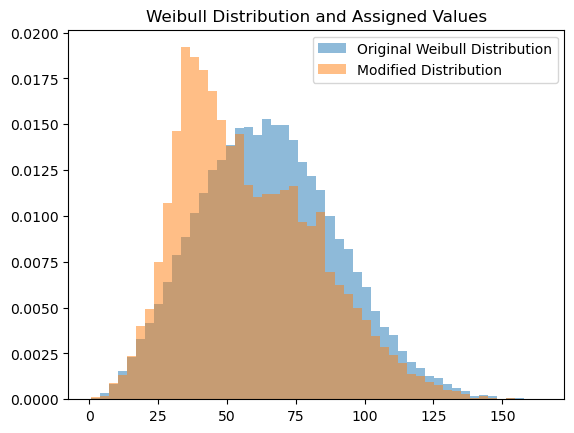

In [32]:
from scipy.stats import weibull_min
# User-defined parameters
shape_param = 2.8
scale_param = 73.5
sample_size = df_combined.shape[0]
# threshold_value = 50

def generate_weibull_samples(shape, scale, size):
    return weibull_min.rvs(shape, scale=scale, size=size)

# Generate Weibull-distributed samples
weibull_samples = generate_weibull_samples(shape_param, scale_param, sample_size)

def assign_samples_to_new_column(df, original_column, threshold_column, samples):
    new_column_name = f'{original_column}_modified'
    mask = df[original_column] > df[threshold_column]
    df[new_column_name] = df[original_column]
    df.loc[mask, new_column_name] = samples[mask]
    return df

# Assign samples based on conditions using dynamic threshold
df_combined = assign_samples_to_new_column(df_combined, 'weighted_avg_age', 'Percent_Built', weibull_samples)

# Display the modified DataFrame
print("\nDataFrame after assignment:")
# print(df_combined.head())
# Plot the Weibull distribution and assigned values
plt.hist(weibull_samples, bins=50, density=True, alpha=0.5, label='Original Weibull Distribution')
plt.hist(df_combined['weighted_avg_age_modified'], bins=50, density=True, alpha=0.5, label='Modified Distribution')
plt.legend()
plt.title('Weibull Distribution and Assigned Values')
plt.show()

In [63]:
df_combined[df_combined['NAMELSAD'] == 'Chicago city'][['HUs_Total', 'YB_2020_or_later',
       'YB_2010_2019', 'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979',
       'YB_1940_1959', 'YB_1939_or_earlier', 'STRUC_detached_1',
       'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4', 'STRUC_apt_5_9',
       'STRUC_apt_10_more', 'STRUC_mobile_or_other', 
       'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'weighted_avg_age_modified']]

,HUs_Total,YB_2020_or_later,YB_2010_2019,YB_2000_2009,YB_1980_1999,YB_1960_1979,YB_1940_1959,YB_1939_or_earlier,STRUC_detached_1,STRUC_attached_1,STRUC_apt_2,STRUC_apt_3_4,STRUC_apt_5_9,STRUC_apt_10_more,STRUC_mobile_or_other,Year_Built,Percent_Built,weighted_avg_age,weighted_avg_age_modified
7645,1112581,0.0,3.8,8.1,10.1,17.6,20.9,39.4,27.3,3.5,13.2,14.2,11.4,30.0,0.3,YB_1939_or_earlier,39.4,63.894,86.557979


In [89]:
def generate_weibull_samples(shape, scale, size):
    return weibull_min.rvs(shape, scale=scale, size=size)

shape_param = 2.8
scale_param = 73.5
sample_size = df_combined.loc[7645, 'HUs_Total']
generate_weibull_samples(shape_param, scale_param, sample_size)


def assign_samples_to_new_column(df, original_column, threshold_column, samples):
    new_column_name = f'{original_column}_modified'
    mask = df[original_column] > df[threshold_column]
    df[new_column_name] = df[original_column]
    df.loc[mask, new_column_name] = samples[mask]
    return df

# Set the percentages for different ranges
older_85_or_more = df_combined.loc[7645, 'YB_1939_or_earlier']
older_65_to_84 = df_combined.loc[7645, 'YB_1940_1959']
older_45_to_64 = df_combined.loc[7645, 'YB_1960_1979']
older_25_to_44 = df_combined.loc[7645, 'YB_1980_1999']
older_15_to_24 = df_combined.loc[7645, 'YB_2000_2009']
older_05_to_14 = df_combined.loc[7645, 'YB_2010_2019']
older_04_or_less = df_combined.loc[7645, 'YB_2020_or_later']

# Generate random samples based on conditions
size_older_85_or_more = int(older_85_or_more * sample_size/100)
size_older_65_to_84 = int(older_65_to_84 * sample_size/100)
size_older_45_to_64 = int(older_45_to_64 * sample_size/100)
size_older_25_to_44 = int(older_25_to_44 * sample_size/100)
size_older_15_to_24 = int(older_15_to_24 * sample_size/100)
size_older_05_to_14 = int(older_05_to_14 * sample_size/100)
size_older_04_or_less = int(older_04_or_less * sample_size/100)


samples_older_85_or_more = generate_weibull_samples(shape_param, 85, size_older_85_or_more)
sample_older_65_to_84 = generate_weibull_samples(shape_param, 75, size_older_65_to_84)
sample_older_45_to_64 = generate_weibull_samples(shape_param, 55, size_older_45_to_64)
sample_older_25_to_44 = generate_weibull_samples(shape_param, 35, size_older_25_to_44)
sample_older_15_to_24 = generate_weibull_samples(shape_param, 20, size_older_15_to_24)
sample_older_05_to_14 = generate_weibull_samples(shape_param, 10, size_older_05_to_14)
sample_older_04_or_less = generate_weibull_samples(shape_param, 2, size_older_04_or_less)



np.average(np.concatenate([samples_older_85_or_more, sample_older_65_to_84, sample_older_45_to_64,
                                       sample_older_25_to_44, sample_older_15_to_24, sample_older_05_to_14,
                                       sample_older_04_or_less]))

57.328186976535875

In [94]:
samples_older_85_or_more = generate_weibull_samples(shape_param, 85, size_older_85_or_more)
samples_older_85_or_more
size_older_85_or_more, size_older_65_to_84, size_older_45_to_64, size_older_25_to_44, size_older_15_to_24, size_older_05_to_14, size_older_04_or_less

(438356, 232529, 195814, 112370, 90119, 42278, 0)

In [107]:
samples_older_85_or_more = generate_weibull_samples(shape_param, 95, size_older_85_or_more)
sample_older_65_to_84 = generate_weibull_samples(shape_param, 85, size_older_65_to_84)
sample_older_45_to_64 = generate_weibull_samples(shape_param, 65, size_older_45_to_64)
sample_older_25_to_44 = generate_weibull_samples(shape_param, 45, size_older_25_to_44)
sample_older_15_to_24 = generate_weibull_samples(shape_param, 30, size_older_15_to_24)
sample_older_05_to_14 = generate_weibull_samples(shape_param, 20, size_older_05_to_14)
sample_older_04_or_less = generate_weibull_samples(shape_param, 12, size_older_04_or_less)



data_sample = np.concatenate([samples_older_85_or_more, sample_older_65_to_84, sample_older_45_to_64,
                                       sample_older_25_to_44, sample_older_15_to_24, sample_older_05_to_14,
                                       sample_older_04_or_less])

In [118]:
e_dataframe = pd.DataFrame(data_sample)      

e_dataframe = e_dataframe.rename(index=str, columns={0:'new_column_name'})

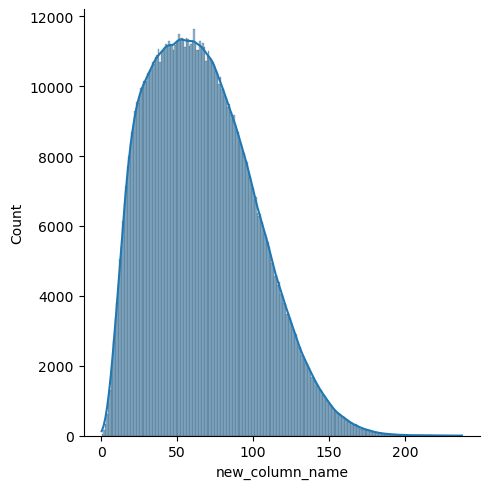

In [120]:
import seaborn as sns
sns.displot(data=e_dataframe, x='new_column_name', kde=True)


In [69]:
import numpy as np
import pandas as pd
from scipy.stats import weibull_min

# Function to generate random samples from a Weibull distribution
def generate_weibull_samples(shape, scale, size):
    return weibull_min.rvs(shape, scale=scale, size=size)

# Create a sample DataFrame with a column 'Threshold'
data = {'Threshold': np.random.uniform(0, 100, 1000)}
df = pd.DataFrame(data)

# Set the percentages for different ranges
percentage_less_than_20 = 0.2
percentage_20_to_40 = 0.2
percentage_over_40 = 0.6

# Generate random samples based on conditions
size_less_than_20 = int(percentage_less_than_20 * len(df))
size_20_to_40 = int(percentage_20_to_40 * len(df))
size_over_40 = len(df) - size_less_than_20 - size_20_to_40



C:\Users\uttar\AppData\Local\Temp\ipykernel_24260\3718472915.py:6: RuntimeWarning: invalid value encountered in power
  return (shape / scale) * ((x / scale) ** (shape - 1)) * np.exp(-((x / scale) ** shape))
C:\Users\uttar\AppData\Local\Temp\ipykernel_24260\3718472915.py:6: RuntimeWarning: divide by zero encountered in power
  return (shape / scale) * ((x / scale) ** (shape - 1)) * np.exp(-((x / scale) ** shape))


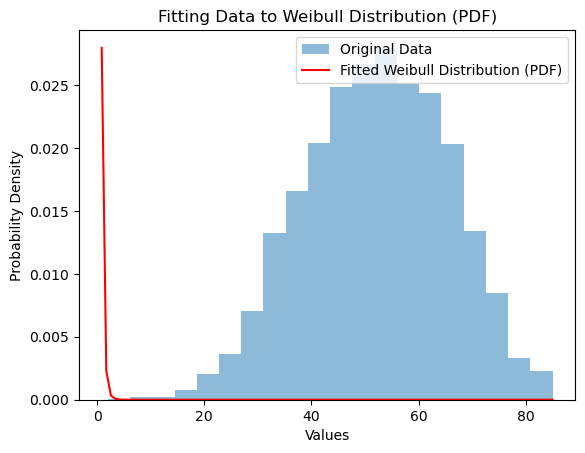

Fitted Weibull Distribution Parameters:
Shape parameter: 0.5549410040748529
Scale parameter: 0.05310692368408891


In [54]:
from scipy.optimize import curve_fit
data = df_combined['weighted_avg_age'].dropna()

# Define the Weibull probability density function (PDF)
def weibull_pdf(x, shape, scale):
    return (shape / scale) * ((x / scale) ** (shape - 1)) * np.exp(-((x / scale) ** shape))

# Create bins for histogram
hist_values, bin_edges = np.histogram(data, bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Fit the data to the Weibull distribution using curve_fit
params, covariance = curve_fit(weibull_pdf, bin_centers, hist_values, p0=[2, 2])

# Extract the shape and scale parameters from the fitting
fitted_shape, fitted_scale = params

# Plot the original data and the fitted Weibull distribution
plt.hist(data, bins=20, density=True, alpha=0.5, label='Original Data')
x_values = np.linspace(0, np.max(data), 100)
plt.plot(x_values, weibull_pdf(x_values, fitted_shape, fitted_scale), 'r-', label='Fitted Weibull Distribution (PDF)')
plt.legend()
plt.title('Fitting Data to Weibull Distribution (PDF)')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.show()

print("Fitted Weibull Distribution Parameters:")
print("Shape parameter:", fitted_shape)
print("Scale parameter:", fitted_scale)

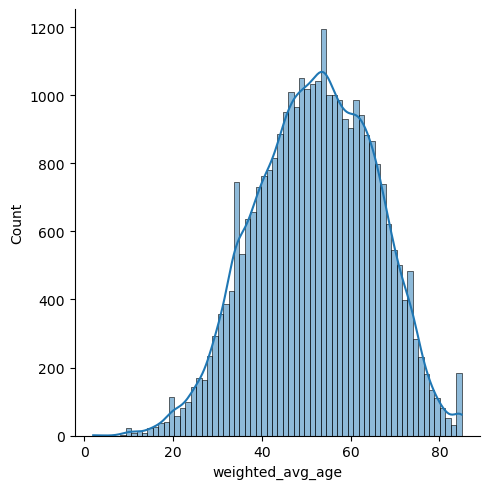

In [53]:
sns.displot(data=df_combined, x='weighted_avg_age', kde=True)

In [39]:
df_combined[['%built', 'NAME_y', 'HUs_Total', 'STRUC_detached_1',
       'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4', 'STRUC_apt_5_9',
       'STRUC_apt_10_more', 'STRUC_mobile_or_other',
       'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'weighted_avg_age_modified']]

,%built,NAME_y,HUs_Total,STRUC_detached_1,STRUC_attached_1,STRUC_apt_2,STRUC_apt_3_4,STRUC_apt_5_9,STRUC_apt_10_more,STRUC_mobile_or_other,Year_Built,Percent_Built,weighted_avg_age,weighted_avg_age_modified
0,0.074143,"Ardmore town, Alabama",584,75.2,3.1,1.9,3.6,9.4,6.0,0.9,YB_1980_1999,31.8,42.987,83.991448
1,0.026826,"Mooresville town, Alabama",32,100.0,0.0,0.0,0.0,0.0,0.0,0.0,YB_1939_or_earlier,71.9,69.229,69.229000
2,0.025051,"Somerville town, Alabama",257,53.3,1.9,6.2,3.9,0.0,0.0,34.6,YB_1980_1999,46.7,40.694,40.694000
3,0.066620,"Trinity town, Alabama",844,85.7,0.0,0.0,0.0,0.0,0.0,14.3,YB_1980_1999,39.8,38.508,38.508000
4,0.026955,"Goshen town, Alabama",114,71.9,0.0,0.0,0.0,0.0,0.0,28.1,YB_1980_1999,32.5,51.828,25.457707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31900,0.244627,"Voladoras comunidad, Puerto Rico",254,91.3,8.7,0.0,0.0,0.0,0.0,0.0,YB_1960_1979,39.0,44.566,50.343430
31901,0.209362,"Yabucoa zona urbana, Puerto Rico",2598,75.9,12.4,1.4,0.9,6.1,3.0,0.3,YB_1960_1979,54.2,47.254,47.254000
31902,0.300494,"Yauco zona urbana, Puerto Rico",5354,77.2,11.7,1.5,2.7,5.5,1.5,0.0,YB_1960_1979,44.8,45.245,33.076298
31903,0.039720,"Yaurel comunidad, Puerto Rico",377,96.6,3.4,0.0,0.0,0.0,0.0,0.0,YB_1980_1999,52.3,43.134,43.134000


In [36]:
df_combined['weighted_avg_age'].describe()

count    31388.000000
mean        52.180434
std         13.339690
min          2.000000
25%         42.755500
50%         52.505500
75%         62.063000
max         85.000000
Name: weighted_avg_age, dtype: float64

In [37]:
# df_combined[['surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020']]
# df_attributes .columns


In [38]:
df_attributes = pd.read_csv(r'D:\Work\Box Sync\Trends_all states\Output from Analysis\df_attributes.csv', index_col =0, dtype= {'GEOID':'str'})

In [39]:
df_with_attr = df_combined.merge(df_attributes[['GEOID', 'weighted_HU_density_sqmi', 'label',
       'density_km2', 'CensusPop_20', 'future trend from SSP 1',
       'future trend from SSP 2', 'future trend from SSP 3',
       'future trend from SSP 4', 'future trend from SSP 5', 'REGION',
       'DIVISION', 'tt_2_work_place', 'veh_<=_1','veh_2_or+','city type', 'median_income',]], on = 'GEOID')

In [40]:
import seaborn as sns
# sns.relplot(data=df_with_attr, x='CensusPop_20', y='surface_2020', size = 1, hue = 'REGION', col='city type', col_wrap=2)

In [41]:
# sns.relplot(data=df_with_attr, x='CensusPop_20', y='volume_2020', size = 1, hue = 'REGION', col='city type', col_wrap=2)

In [42]:
df_with_attr[[ 'NAME_x', 'TOTALAREA_SQKM_2020',
       'surface', 'surface_1990', 'surface_1995', 'surface_2000',
       'surface_2010', 'surface_2015', 'surface_2020','HUs_Total', 'YB_2020_or_later',
       'YB_2010_2019', 'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979',
       'YB_1940_1959', 'YB_1939_or_earlier', 'STRUC_detached_1',
       'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4', 'STRUC_apt_5_9',
       'STRUC_apt_10_more', 'STRUC_mobile_or_other', 
       'Year_Built', 'Percent_Built']]

,NAME_x,TOTALAREA_SQKM_2020,surface,surface_1990,surface_1995,surface_2000,surface_2010,surface_2015,surface_2020,HUs_Total,...,YB_1939_or_earlier,STRUC_detached_1,STRUC_attached_1,STRUC_apt_2,STRUC_apt_3_4,STRUC_apt_5_9,STRUC_apt_10_more,STRUC_mobile_or_other,Year_Built,Percent_Built
0,Ardmore,5.311725,0.213926,0.238099,0.266763,0.295982,0.353086,0.380669,0.392207,584,...,10.3,75.2,3.1,1.9,3.6,9.4,6.0,0.9,YB_1980_1999,31.8
1,Mooresville,0.771916,0.008922,0.011022,0.011247,0.011465,0.015290,0.016902,0.017339,32,...,71.9,100.0,0.0,0.0,0.0,0.0,0.0,0.0,YB_1939_or_earlier,71.9
2,Somerville,8.907674,0.119320,0.144343,0.160119,0.177308,0.205661,0.218071,0.222847,257,...,1.6,53.3,1.9,6.2,3.9,0.0,0.0,34.6,YB_1980_1999,46.7
3,Trinity,12.881809,0.373842,0.426965,0.514095,0.613220,0.763619,0.831298,0.856840,844,...,0.0,85.7,0.0,0.0,0.0,0.0,0.0,14.3,YB_1980_1999,39.8
4,Goshen,6.674844,0.094460,0.108613,0.124507,0.141890,0.165077,0.175093,0.178836,114,...,9.6,71.9,0.0,0.0,0.0,0.0,0.0,28.1,YB_1980_1999,32.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31900,Voladoras,0.393405,0.069068,0.089347,0.090593,0.091835,0.094316,0.095463,0.096238,254,...,0.0,91.3,8.7,0.0,0.0,0.0,0.0,0.0,YB_1960_1979,39.0
31901,Yabucoa,3.365106,0.490116,0.599489,0.616183,0.633564,0.675798,0.694237,0.704466,2598,...,0.2,75.9,12.4,1.4,0.9,6.1,3.0,0.3,YB_1960_1979,54.2
31902,Yauco,7.505995,1.523624,1.776826,1.909512,2.045699,2.090757,2.133182,2.253377,5354,...,1.3,77.2,11.7,1.5,2.7,5.5,1.5,0.0,YB_1960_1979,44.8
31903,Yaurel,3.076256,0.054406,0.090009,0.091458,0.093017,0.108769,0.116533,0.122190,377,...,0.0,96.6,3.4,0.0,0.0,0.0,0.0,0.0,YB_1980_1999,52.3
